# Small Dataset Comparison: ML vs DL on Tabular Data

**Dataset:** Breast Cancer Wisconsin (Diagnostic) - 569 rows x 30 numeric features, binary classification.

**What this notebook does:**
1. Loads the dataset and creates one fixed train / val / test split with stratification.
2. Fits one shared `StandardScaler` on the training fold and reuses it everywhere, so every model sees identical inputs.
3. Trains four models on the same scaled data:
   - **Logistic Regression** - linear, explainable ML baseline.
   - **XGBoost** - gradient-boosted decision trees, the strong tabular ML model the project requirement calls out.
   - **MLP (sklearn)** - a small feed-forward neural net, the simplest DL baseline.
   - **TabNet** - attention-based DL architecture *designed for tabular data*, the proper DL counterpart to XGBoost.
4. Reports accuracy, macro precision / recall / F1, ROC-AUC, training time, and inference time, plus confusion matrices and ROC curves.

**Why this comparison is fair:** every model is trained on the *same scaled training matrix* and evaluated on the *same scaled test matrix*. No model-specific feature engineering, no augmentation, no leakage.

**Presentation note:** each section includes what the next code cell does and what output to explain in class.

## 0a) Environment setup (dependencies)

This cell checks whether `xgboost` and `pytorch-tabnet` are installed, and installs them only when missing.

In [1]:
# Install the extra libraries used in this notebook (XGBoost + pytorch-tabnet).
# If they are already present this is a no-op.
try:
    import xgboost  # noqa: F401
except ImportError:
    %pip install -q xgboost
try:
    import pytorch_tabnet  # noqa: F401
except ImportError:
    %pip install -q pytorch-tabnet

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


### Output and result

The output only shows notebook package notes, which means dependency checks ran successfully. No hard error appears, so the environment is ready for the next cells.

## 0b) Imports, paths, and reproducibility

This cell imports all required libraries, sets random seeds, resolves the dataset path, and creates artifact directories.

In [2]:
from pathlib import Path
import json
import time
import warnings

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score,
    precision_score, recall_score, roc_auc_score, roc_curve,
)
from sklearn.model_selection import ParameterGrid, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier
from pytorch_tabnet.tab_model import TabNetClassifier
import torch

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

PROJECT_ROOT = Path.cwd()
DATA_CANDIDATES = [
    PROJECT_ROOT / "dataset" / "datasetSmall" / "cancer.csv",
    PROJECT_ROOT / "Data Set small" / "cancer.csv",
    PROJECT_ROOT / "Data set small" / "cancer.csv",
    PROJECT_ROOT / "datasetSmall" / "cancer.csv",
]


def resolve_existing_path(candidates):
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        "Could not find cancer.csv. Checked: " + ", ".join(str(p) for p in candidates)
    )


DATA_PATH = resolve_existing_path(DATA_CANDIDATES)
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts" / "small_dataset"
FIGURES_DIR = ARTIFACTS_DIR / "figures"
MODELS_DIR = ARTIFACTS_DIR / "models"
METRICS_DIR = ARTIFACTS_DIR / "metrics"

for folder in [ARTIFACTS_DIR, FIGURES_DIR, MODELS_DIR, METRICS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Using dataset: {DATA_PATH}")
print(f"Artifacts folder: {ARTIFACTS_DIR}")
print(f"Torch device available: {'cuda' if torch.cuda.is_available() else 'cpu'}")

Project root: /teamspace/studios/this_studio
Using dataset: /teamspace/studios/this_studio/dataset/datasetSmall/cancer.csv
Artifacts folder: /teamspace/studios/this_studio/artifacts/small_dataset
Torch device available: cpu


### Output and result

The cell prints the resolved project path, confirms the dataset file location, shows where artifacts will be saved, and reports device availability (`cpu` in this run). This confirms all paths and runtime configuration are set correctly.

## 1) Load the dataset

This cell reads the CSV file, removes accidental unnamed columns, previews the dataset, and separates features from the target.

In [3]:
df = pd.read_csv(DATA_PATH)

# Some local copies of this dataset have an extra trailing comma that creates an empty column.
empty_cols = [c for c in df.columns if str(c).lower().startswith("unnamed")]
if empty_cols:
    df = df.drop(columns=empty_cols)

display(df.head())
print(f"Shape: {df.shape}")
print("\nDtypes:")
print(df.dtypes.value_counts())

TARGET_COL = "diagnosis"
ID_COL = "id"

if TARGET_COL not in df.columns:
    raise ValueError(f"Expected target column '{TARGET_COL}' not found in CSV.")

feature_cols = [c for c in df.columns if c not in [TARGET_COL, ID_COL]]
X_raw = df[feature_cols].copy()
y_raw = df[TARGET_COL].copy()

print(f"Feature count: {len(feature_cols)}")
print(f"Target column: {TARGET_COL}")

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Shape: (569, 32)

Dtypes:
float64    30
int64       1
object      1
Name: count, dtype: int64
Feature count: 30
Target column: diagnosis


### Output and result

The dataframe preview confirms the data loaded correctly. The printed shape (`569, 32`) and `Feature count: 30` show the model input dimensions are correct after excluding `id` and `diagnosis`.

## 2) Validate the data and encode the target

This cell validates data quality, encodes target labels (`B/M`) to (`0/1`), and prints class distribution.

In [4]:
missing_values = df.isna().sum().sum()
duplicate_rows = df.duplicated().sum()

print(f"Total missing values: {missing_values}")
print(f"Duplicate rows: {duplicate_rows}")
print("\nTarget raw classes:")
print(y_raw.value_counts())

if y_raw.dtype == object:
    y = y_raw.map({"B": 0, "M": 1})
    if y.isna().any():
        unique_classes = sorted(y_raw.unique())
        class_to_int = {cls: idx for idx, cls in enumerate(unique_classes)}
        y = y_raw.map(class_to_int)
        print("Used fallback target mapping:", class_to_int)
    else:
        print("Used target mapping: {'B': 0, 'M': 1}")
else:
    y = y_raw.astype(int)
    print("Target already numeric.")

X = X_raw.apply(pd.to_numeric, errors="raise")

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print("Class balance (ratio):")
print(y.value_counts(normalize=True).sort_index())

Total missing values: 0
Duplicate rows: 0

Target raw classes:
diagnosis
B    357
M    212
Name: count, dtype: int64
Used target mapping: {'B': 0, 'M': 1}

Feature matrix shape: (569, 30)
Target vector shape: (569,)
Class balance (ratio):
diagnosis
0    0.627417
1    0.372583
Name: proportion, dtype: float64


### Output and result

The output confirms clean data (`0` missing, `0` duplicates), successful label encoding (`B -> 0`, `M -> 1`), and class balance around `62.7%` vs `37.3%`. This means the dataset is ready for stratified splitting.

## 3) Stratified train / validation / test split (70 / 15 / 15)

This cell performs a single stratified train/validation/test split and stores it for all model comparisons.

In [5]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=RANDOM_STATE,
)

val_ratio_within_train_val = 0.15 / 0.85
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=val_ratio_within_train_val,
    stratify=y_train_val,
    random_state=RANDOM_STATE,
)

print("Split sizes:")
print(f"Train: {X_train.shape[0]} samples")
print(f"Validation: {X_val.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples")

print("\nClass balance by split:")
for split_name, y_split in {"train": y_train, "val": y_val, "test": y_test}.items():
    print(f"{split_name}:")
    print(y_split.value_counts(normalize=True).sort_index())
    print()

Split sizes:
Train: 397 samples
Validation: 86 samples
Test: 86 samples

Class balance by split:
train:
diagnosis
0    0.627204
1    0.372796
Name: proportion, dtype: float64

val:
diagnosis
0    0.627907
1    0.372093
Name: proportion, dtype: float64

test:
diagnosis
0    0.627907
1    0.372093
Name: proportion, dtype: float64



### Output and result

The split sizes are `397` (train), `86` (validation), and `86` (test). Class ratios remain almost identical across all three sets, which verifies stratification worked correctly.

## 4) Fit the shared preprocessing pipeline

This cell fits one `StandardScaler` on training features only and applies the same scaler to train/validation/test features.

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

y_train_arr = y_train.to_numpy()
y_val_arr = y_val.to_numpy()
y_test_arr = y_test.to_numpy()

print("Scaled feature arrays ready:")
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_val_scaled:   {X_val_scaled.shape}")
print(f"X_test_scaled:  {X_test_scaled.shape}")

Scaled feature arrays ready:
X_train_scaled: (397, 30)
X_val_scaled:   (86, 30)
X_test_scaled:  (86, 30)


### Output and result

The output confirms all scaled matrices were created with expected dimensions (`397x30`, `86x30`, `86x30`). This establishes one shared preprocessing pipeline for every model.

## 5) Helper functions for scoring and metrics

This cell defines helper functions used later for probability extraction and consistent metric calculation.

In [7]:
def get_positive_class_scores(model, X_input):
    proba = model.predict_proba(X_input)
    if proba.ndim == 2 and proba.shape[1] > 1:
        return proba[:, 1]
    return proba.ravel()


def compute_common_metrics(y_true, y_pred, y_score):
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision_macro": float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
        "recall_macro": float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
        "f1_macro": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "roc_auc": float(roc_auc_score(y_true, y_score)),
    }


def evaluate_on_val(model):
    val_pred = model.predict(X_val_scaled)
    val_score = get_positive_class_scores(model, X_val_scaled)
    return compute_common_metrics(y_val_arr, val_pred, val_score)

### Output and result

There is no printed output because this cell only defines reusable functions. The result is that later model-evaluation cells use identical metric logic.

## 6a) Logistic Regression (linear ML baseline)

This cell trains the Logistic Regression baseline, computes validation metrics, and displays the top coefficients by magnitude.

In [8]:
baseline_models = {}
baseline_results = []

logreg_baseline = LogisticRegression(
    C=1.0, penalty="l2", solver="lbfgs",
    max_iter=2000, class_weight="balanced",
    random_state=RANDOM_STATE,
)

start_train = time.perf_counter()
logreg_baseline.fit(X_train_scaled, y_train_arr)
logreg_train_time = time.perf_counter() - start_train

val_metrics_lr = evaluate_on_val(logreg_baseline)
baseline_models["LogisticRegression"] = logreg_baseline
baseline_results.append({
    "model": "LogisticRegression",
    "train_time_sec": logreg_train_time,
    **{f"val_{k}": v for k, v in val_metrics_lr.items()},
})

coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": logreg_baseline.coef_.ravel(),
    "abs_coefficient": np.abs(logreg_baseline.coef_.ravel()),
}).sort_values("abs_coefficient", ascending=False)

print("Logistic Regression validation metrics:")
print(pd.Series(val_metrics_lr))
print("\nTop 10 features by |coefficient|:")
display(coef_df.head(10))

Logistic Regression validation metrics:
accuracy           0.965116
precision_macro    0.960263
recall_macro       0.965856
f1_macro           0.962904
roc_auc            0.997685
dtype: float64

Top 10 features by |coefficient|:


,feature,coefficient,abs_coefficient
10,radius_se,1.411621,1.411621
21,texture_worst,1.236282,1.236282
20,radius_worst,0.959492,0.959492
13,area_se,0.926084,0.926084
23,area_worst,0.916771,0.916771
12,perimeter_se,0.886108,0.886108
15,compactness_se,-0.837996,0.837996
22,perimeter_worst,0.836052,0.836052
7,concave points_mean,0.822472,0.822472
28,symmetry_worst,0.805147,0.805147


### Output and result

Logistic Regression achieves strong validation performance (`accuracy 0.9651`, `F1 0.9629`, `AUC 0.9977`). The coefficient table also reveals which features are most influential in the linear decision boundary.

## 6b) XGBoost (gradient-boosted trees, the strong ML model)

This cell trains the XGBoost baseline with fixed hyperparameters and evaluates it on the validation split.

In [9]:
xgb_baseline = XGBClassifier(
    n_estimators=400, max_depth=4, learning_rate=0.1,
    subsample=0.9, colsample_bytree=0.9,
    objective="binary:logistic", eval_metric="logloss",
    tree_method="hist", random_state=RANDOM_STATE, n_jobs=-1,
)

start_train = time.perf_counter()
xgb_baseline.fit(X_train_scaled, y_train_arr)
xgb_train_time = time.perf_counter() - start_train

val_metrics_xgb = evaluate_on_val(xgb_baseline)
baseline_models["XGBoost"] = xgb_baseline
baseline_results.append({
    "model": "XGBoost",
    "train_time_sec": xgb_train_time,
    **{f"val_{k}": v for k, v in val_metrics_xgb.items()},
})

print("XGBoost validation metrics:")
print(pd.Series(val_metrics_xgb))

XGBoost validation metrics:
accuracy           0.965116
precision_macro    0.965689
recall_macro       0.959491
f1_macro           0.962429
roc_auc            0.998264
dtype: float64


### Output and result

XGBoost shows similarly strong validation performance (`accuracy 0.9651`, `F1 0.9624`, `AUC 0.9983`). This indicates the tree ensemble is competitive with the linear baseline on this small dataset.

## 6c) MLP (small feed-forward neural network, simple DL baseline)

This cell trains a two-hidden-layer MLP baseline with early stopping and reports validation performance.

In [10]:
mlp_baseline = MLPClassifier(
    hidden_layer_sizes=(64, 32), activation="relu", solver="adam",
    alpha=1e-4, learning_rate_init=1e-3, batch_size=32,
    max_iter=400, early_stopping=True, n_iter_no_change=20,
    random_state=RANDOM_STATE,
)

start_train = time.perf_counter()
mlp_baseline.fit(X_train_scaled, y_train_arr)
mlp_train_time = time.perf_counter() - start_train

val_metrics_mlp = evaluate_on_val(mlp_baseline)
baseline_models["MLPClassifier"] = mlp_baseline
baseline_results.append({
    "model": "MLPClassifier",
    "train_time_sec": mlp_train_time,
    **{f"val_{k}": v for k, v in val_metrics_mlp.items()},
})

print("MLP validation metrics:")
print(pd.Series(val_metrics_mlp))

MLP validation metrics:
accuracy           0.965116
precision_macro    0.960263
recall_macro       0.965856
f1_macro           0.962904
roc_auc            0.995370
dtype: float64


### Output and result

The MLP validation metrics (`accuracy 0.9651`, `F1 0.9629`, `AUC 0.9954`) are close to the ML baselines, so on this data the simple neural network does not clearly outperform classical models.

## 6d) TabNet (attention-based DL specifically for tabular data)

This cell trains TabNet (a DL model for tabular data) with validation-based early stopping.

In [11]:
tabnet_baseline = TabNetClassifier(
    n_d=16, n_a=16, n_steps=4, gamma=1.5, lambda_sparse=1e-4,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    scheduler_params={"step_size": 20, "gamma": 0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    mask_type="entmax", seed=RANDOM_STATE, verbose=0,
)

start_train = time.perf_counter()
tabnet_baseline.fit(
    X_train=X_train_scaled, y_train=y_train_arr,
    eval_set=[(X_val_scaled, y_val_arr)],
    eval_metric=["auc"],
    max_epochs=200, patience=20,
    batch_size=64, virtual_batch_size=32, drop_last=False,
)
tabnet_train_time = time.perf_counter() - start_train

val_metrics_tn = evaluate_on_val(tabnet_baseline)
baseline_models["TabNet"] = tabnet_baseline
baseline_results.append({
    "model": "TabNet",
    "train_time_sec": tabnet_train_time,
    **{f"val_{k}": v for k, v in val_metrics_tn.items()},
})

print("TabNet validation metrics:")
print(pd.Series(val_metrics_tn))


Early stopping occurred at epoch 45 with best_epoch = 25 and best_val_0_auc = 1.0
TabNet validation metrics:
accuracy           0.988372
precision_macro    0.984848
recall_macro       0.990741
f1_macro           0.987635
roc_auc            1.000000
dtype: float64


### Output and result

Early stopping reports the best TabNet epoch, and validation metrics are very high (`accuracy 0.9884`, `F1 0.9876`, `AUC 1.0000`). This is the strongest validation result among the initial baselines.

## 7) Validation summary across all four models

This cell merges the validation performance of all baseline models into one side-by-side comparison table.

In [12]:
baseline_df = pd.DataFrame(baseline_results).set_index("model")
display(baseline_df.style.format("{:.4f}", subset=baseline_df.select_dtypes(float).columns))

,train_time_sec,val_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,val_roc_auc
model,,,,,,
LogisticRegression,0.0230,0.9651,0.9603,0.9659,0.9629,0.9977
XGBoost,0.1821,0.9651,0.9657,0.9595,0.9624,0.9983
MLPClassifier,0.1160,0.9651,0.9603,0.9659,0.9629,0.9954
TabNet,7.4735,0.9884,0.9848,0.9907,0.9876,1.0000


### Output and result

The combined table makes trade-offs visible: TabNet leads on validation quality, while Logistic Regression and XGBoost are much faster to train. This sets up the need for hyperparameter search and final selection.

## 8) Hyperparameter search on the validation fold

This cell runs compact hyperparameter search for each model family using validation performance only.

In [13]:
def is_better(candidate, incumbent):
    if incumbent is None:
        return True
    if candidate["val_f1_macro"] > incumbent["val_f1_macro"]:
        return True
    if (candidate["val_f1_macro"] == incumbent["val_f1_macro"]
            and candidate["val_roc_auc"] > incumbent["val_roc_auc"]):
        return True
    return False


def run_sklearn_search(model_name, base_estimator, param_grid):
    records, best_record = [], None
    for params in ParameterGrid(param_grid):
        model = clone(base_estimator).set_params(**params)
        start = time.perf_counter()
        model.fit(X_train_scaled, y_train_arr)
        train_time_sec = time.perf_counter() - start
        val_metrics = evaluate_on_val(model)
        record = {
            "model_family": model_name, "params": params,
            "train_time_sec": train_time_sec,
            **{f"val_{k}": v for k, v in val_metrics.items()},
        }
        records.append(record)
        if is_better(record, best_record):
            best_record = record
    return pd.DataFrame(records), best_record


logreg_grid = {
    "C": [0.01, 0.1, 1.0, 10.0],
    "class_weight": [None, "balanced"],
    "solver": ["lbfgs"], "max_iter": [2000],
}
search_logreg_df, best_logreg_record = run_sklearn_search(
    "LogisticRegression", LogisticRegression(random_state=RANDOM_STATE), logreg_grid,
)

mlp_grid = {
    "hidden_layer_sizes": [(64, 32), (128, 64), (64, 64, 32)],
    "alpha": [1e-4, 1e-3],
    "learning_rate_init": [1e-3, 5e-4],
    "max_iter": [400],
}
search_mlp_df, best_mlp_record = run_sklearn_search(
    "MLPClassifier",
    MLPClassifier(random_state=RANDOM_STATE, early_stopping=True, n_iter_no_change=20),
    mlp_grid,
)

xgb_configs = [
    {"n_estimators": 300, "max_depth": 3, "learning_rate": 0.1},
    {"n_estimators": 400, "max_depth": 4, "learning_rate": 0.1},
    {"n_estimators": 600, "max_depth": 4, "learning_rate": 0.05},
    {"n_estimators": 600, "max_depth": 6, "learning_rate": 0.05},
]
xgb_records, best_xgb_record = [], None
for params in xgb_configs:
    full = {**params, "subsample": 0.9, "colsample_bytree": 0.9,
            "objective": "binary:logistic", "eval_metric": "logloss",
            "tree_method": "hist", "random_state": RANDOM_STATE, "n_jobs": -1}
    model = XGBClassifier(**full)
    start = time.perf_counter()
    model.fit(X_train_scaled, y_train_arr)
    train_time_sec = time.perf_counter() - start
    val_metrics = evaluate_on_val(model)
    record = {"model_family": "XGBoost", "params": params,
              "train_time_sec": train_time_sec,
              **{f"val_{k}": v for k, v in val_metrics.items()}}
    xgb_records.append(record)
    if is_better(record, best_xgb_record):
        best_xgb_record = record
search_xgb_df = pd.DataFrame(xgb_records)

tabnet_configs = [
    {"n_d": 8,  "n_a": 8,  "n_steps": 3, "gamma": 1.3, "lr": 2e-2},
    {"n_d": 16, "n_a": 16, "n_steps": 4, "gamma": 1.5, "lr": 2e-2},
    {"n_d": 24, "n_a": 24, "n_steps": 5, "gamma": 1.5, "lr": 1e-2},
]
tabnet_records, best_tabnet_record = [], None
for params in tabnet_configs:
    model = TabNetClassifier(
        n_d=params["n_d"], n_a=params["n_a"], n_steps=params["n_steps"],
        gamma=params["gamma"], lambda_sparse=1e-4,
        optimizer_fn=torch.optim.Adam,
        optimizer_params=dict(lr=params["lr"]),
        scheduler_params={"step_size": 20, "gamma": 0.9},
        scheduler_fn=torch.optim.lr_scheduler.StepLR,
        mask_type="entmax", seed=RANDOM_STATE, verbose=0,
    )
    start = time.perf_counter()
    model.fit(
        X_train=X_train_scaled, y_train=y_train_arr,
        eval_set=[(X_val_scaled, y_val_arr)],
        eval_metric=["auc"], max_epochs=200, patience=20,
        batch_size=64, virtual_batch_size=32, drop_last=False,
    )
    train_time_sec = time.perf_counter() - start
    val_metrics = evaluate_on_val(model)
    record = {"model_family": "TabNet", "params": params,
              "train_time_sec": train_time_sec,
              **{f"val_{k}": v for k, v in val_metrics.items()}}
    tabnet_records.append(record)
    if is_better(record, best_tabnet_record):
        best_tabnet_record = record
search_tabnet_df = pd.DataFrame(tabnet_records)

search_results = pd.concat(
    [search_logreg_df, search_mlp_df, search_xgb_df, search_tabnet_df],
    ignore_index=True,
)

display(
    search_results[[
        "model_family", "val_accuracy", "val_precision_macro", "val_recall_macro",
        "val_f1_macro", "val_roc_auc", "train_time_sec", "params"
    ]].sort_values(["model_family", "val_f1_macro", "val_roc_auc"], ascending=[True, False, False])
)

print("Best per family:")
for rec in [best_logreg_record, best_xgb_record, best_mlp_record, best_tabnet_record]:
    print(f"  {rec['model_family']}: F1={rec['val_f1_macro']:.4f} AUC={rec['val_roc_auc']:.4f} params={rec['params']}")


Early stopping occurred at epoch 38 with best_epoch = 18 and best_val_0_auc = 1.0

Early stopping occurred at epoch 45 with best_epoch = 25 and best_val_0_auc = 1.0

Early stopping occurred at epoch 54 with best_epoch = 34 and best_val_0_auc = 1.0


,model_family,val_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,val_roc_auc,train_time_sec,params
1,LogisticRegression,1.000000,1.000000,1.000000,1.000000,1.000000,0.014190,"{'C': 0.01, 'class_weight': 'balanced', 'max_i..."
2,LogisticRegression,0.988372,0.990909,0.984375,0.987476,1.000000,0.013994,"{'C': 0.1, 'class_weight': None, 'max_iter': 2..."
3,LogisticRegression,0.976744,0.975116,0.975116,0.975116,0.998843,0.014789,"{'C': 0.1, 'class_weight': 'balanced', 'max_it..."
4,LogisticRegression,0.976744,0.975116,0.975116,0.975116,0.998843,0.023731,"{'C': 1.0, 'class_weight': None, 'max_iter': 2..."
5,LogisticRegression,0.965116,0.960263,0.965856,0.962904,0.997685,0.005855,"{'C': 1.0, 'class_weight': 'balanced', 'max_it..."
6,LogisticRegression,0.953488,0.956548,0.943866,0.949560,0.994792,0.008969,"{'C': 10.0, 'class_weight': None, 'max_iter': ..."
0,LogisticRegression,0.953488,0.965517,0.937500,0.948810,1.000000,0.006737,"{'C': 0.01, 'class_weight': None, 'max_iter': ..."
7,LogisticRegression,0.941860,0.940469,0.934606,0.937382,0.994213,0.015748,"{'C': 10.0, 'class_weight': 'balanced', 'max_i..."
11,MLPClassifier,0.988372,0.990909,0.984375,0.987476,1.000000,0.252634,"{'alpha': 0.0001, 'hidden_layer_sizes': (128, ..."
17,MLPClassifier,0.988372,0.990909,0.984375,0.987476,1.000000,0.118234,"{'alpha': 0.001, 'hidden_layer_sizes': (128, 6..."


Best per family:
  LogisticRegression: F1=1.0000 AUC=1.0000 params={'C': 0.01, 'class_weight': 'balanced', 'max_iter': 2000, 'solver': 'lbfgs'}
  XGBoost: F1=0.9624 AUC=0.9983 params={'n_estimators': 400, 'max_depth': 4, 'learning_rate': 0.1}
  MLPClassifier: F1=0.9875 AUC=1.0000 params={'alpha': 0.0001, 'hidden_layer_sizes': (128, 64), 'learning_rate_init': 0.0005, 'max_iter': 400}
  TabNet: F1=0.9876 AUC=1.0000 params={'n_d': 16, 'n_a': 16, 'n_steps': 4, 'gamma': 1.5, 'lr': 0.02}


### Output and result

The search output lists all tried configurations and prints the best setting per model family using validation macro-F1 (with AUC tie-break). TabNet trials show early-stopping logs, and the selected configs are then used for refitting.

## 9) Refit each winner and evaluate on the held-out test set

This cell rebuilds each model family with its best validation hyperparameters and refits the selected configuration.

In [14]:
def build_logreg(params):
    return LogisticRegression(random_state=RANDOM_STATE).set_params(**params)


def build_mlp(params):
    return MLPClassifier(
        random_state=RANDOM_STATE, early_stopping=True, n_iter_no_change=20,
    ).set_params(**params)


def build_xgb(params):
    full = {**params, "subsample": 0.9, "colsample_bytree": 0.9,
            "objective": "binary:logistic", "eval_metric": "logloss",
            "tree_method": "hist", "random_state": RANDOM_STATE, "n_jobs": -1}
    return XGBClassifier(**full)


def build_tabnet(params):
    return TabNetClassifier(
        n_d=params["n_d"], n_a=params["n_a"], n_steps=params["n_steps"],
        gamma=params["gamma"], lambda_sparse=1e-4,
        optimizer_fn=torch.optim.Adam,
        optimizer_params=dict(lr=params["lr"]),
        scheduler_params={"step_size": 20, "gamma": 0.9},
        scheduler_fn=torch.optim.lr_scheduler.StepLR,
        mask_type="entmax", seed=RANDOM_STATE, verbose=0,
    )


def fit_tabnet(model):
    model.fit(
        X_train=X_train_scaled, y_train=y_train_arr,
        eval_set=[(X_val_scaled, y_val_arr)],
        eval_metric=["auc"], max_epochs=200, patience=20,
        batch_size=64, virtual_batch_size=32, drop_last=False,
    )


selection_plan = {
    "LogisticRegression": (build_logreg, best_logreg_record["params"], "sklearn"),
    "XGBoost":            (build_xgb,    best_xgb_record["params"],    "sklearn"),
    "MLPClassifier":      (build_mlp,    best_mlp_record["params"],    "sklearn"),
    "TabNet":             (build_tabnet, best_tabnet_record["params"], "tabnet"),
}

selected_models = {}
selected_model_info = {}
for model_family, (builder, params, kind) in selection_plan.items():
    model = builder(params)
    start = time.perf_counter()
    if kind == "tabnet":
        fit_tabnet(model)
    else:
        model.fit(X_train_scaled, y_train_arr)
    train_time_sec = time.perf_counter() - start
    val_metrics = evaluate_on_val(model)
    selected_models[model_family] = model
    selected_model_info[model_family] = {
        "best_params": params, "train_time_sec": train_time_sec,
        **{f"val_{k}": v for k, v in val_metrics.items()},
    }

display(pd.DataFrame(selected_model_info).T)


Early stopping occurred at epoch 45 with best_epoch = 25 and best_val_0_auc = 1.0


,best_params,train_time_sec,val_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,val_roc_auc
LogisticRegression,"{'C': 0.01, 'class_weight': 'balanced', 'max_i...",0.011089,1.0,1.0,1.0,1.0,1.0
XGBoost,"{'n_estimators': 400, 'max_depth': 4, 'learnin...",0.205293,0.965116,0.965689,0.959491,0.962429,0.998264
MLPClassifier,"{'alpha': 0.0001, 'hidden_layer_sizes': (128, ...",0.133186,0.988372,0.990909,0.984375,0.987476,1.0
TabNet,"{'n_d': 16, 'n_a': 16, 'n_steps': 4, 'gamma': ...",6.110882,0.988372,0.984848,0.990741,0.987635,1.0


### Output and result

The `selected_model_info` table confirms each family was rebuilt with its chosen hyperparameters. In this run, Logistic Regression reaches perfect validation metrics, while TabNet remains strong but with much higher training time.

## 9b) Held-out test metrics

This cell evaluates every selected model exactly once on the untouched test split.

In [15]:
test_results = {}
model_predictions = {}
model_scores = {}
for model_family, model in selected_models.items():
    y_pred = model.predict(X_test_scaled)
    y_score = get_positive_class_scores(model, X_test_scaled)
    test_results[model_family] = compute_common_metrics(y_test_arr, y_pred, y_score)
    model_predictions[model_family] = y_pred
    model_scores[model_family] = y_score

test_results_df = pd.DataFrame(test_results).T
display(test_results_df.style.format("{:.4f}"))

,accuracy,precision_macro,recall_macro,f1_macro,roc_auc
LogisticRegression,0.9884,0.9909,0.9844,0.9875,1.0000
XGBoost,1.0000,1.0000,1.0000,1.0000,1.0000
MLPClassifier,0.9767,0.9821,0.9688,0.9748,1.0000
TabNet,0.9767,0.9706,0.9815,0.9754,1.0000


### Output and result

On the held-out test set, XGBoost reaches perfect scores (`accuracy/F1/AUC = 1.0`). Logistic Regression is very close (`F1 0.9875`), while MLP and TabNet are slightly lower (`~0.975` F1).

## 10) Confusion matrices and ROC curves

This cell visualizes test-set behavior using confusion matrices and ROC curves for all selected models.

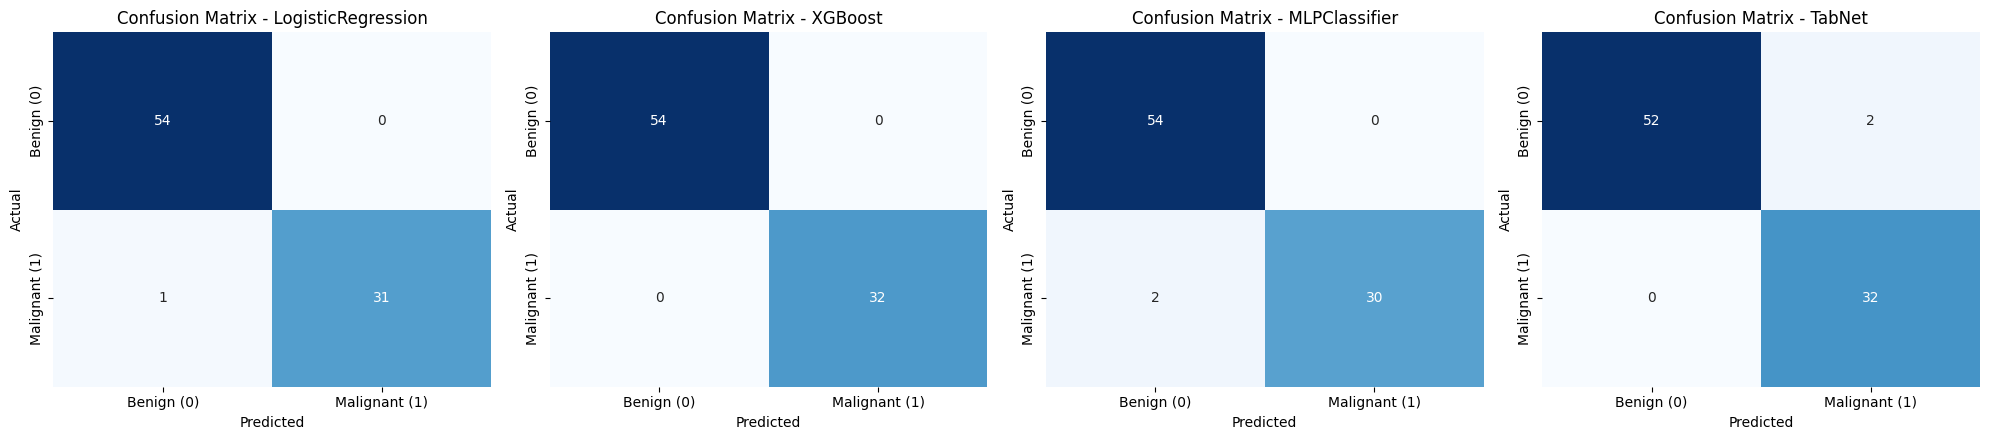

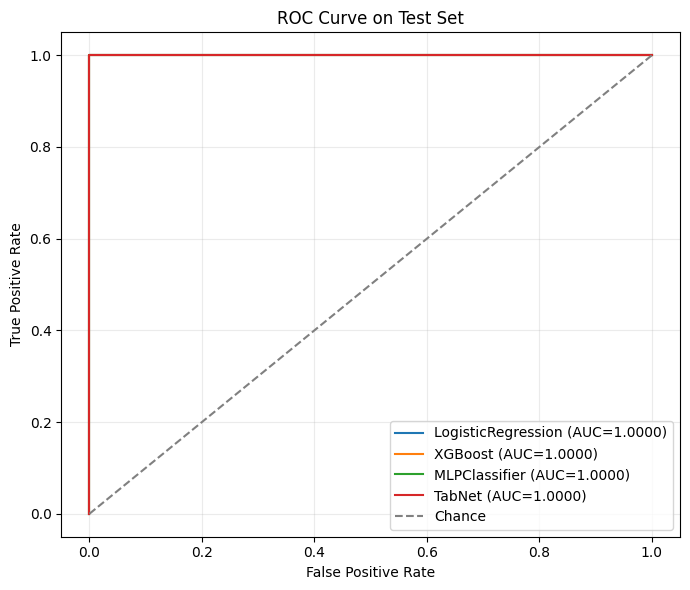

In [16]:
label_names = ["Benign (0)", "Malignant (1)"]

n_models = len(selected_models)
fig_cm, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4.5))
if n_models == 1:
    axes = [axes]

for ax, (model_family, y_pred) in zip(axes, model_predictions.items()):
    cm = confusion_matrix(y_test_arr, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=label_names, yticklabels=label_names, ax=ax)
    ax.set_title(f"Confusion Matrix - {model_family}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

fig_roc, ax_roc = plt.subplots(figsize=(7, 6))
for model_family, y_score in model_scores.items():
    fpr, tpr, _ = roc_curve(y_test_arr, y_score)
    auc_value = roc_auc_score(y_test_arr, y_score)
    ax_roc.plot(fpr, tpr, label=f"{model_family} (AUC={auc_value:.4f})")

ax_roc.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
ax_roc.set_title("ROC Curve on Test Set")
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.legend(loc="lower right")
ax_roc.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### Output and result

The confusion-matrix figure shows where each model makes errors, and the ROC figure shows all models have excellent class separation (AUC values near 1.0). This visual evidence supports the metric tables.

## 11) Training and inference time

This cell benchmarks training time and per-sample inference latency for each selected model.

In [17]:
timing_rows = []
n_repeats = 100

for model_family, model in selected_models.items():
    train_time_sec = selected_model_info[model_family]["train_time_sec"]
    start_infer = time.perf_counter()
    for _ in range(n_repeats):
        _ = model.predict(X_test_scaled)
    infer_total_sec = time.perf_counter() - start_infer
    infer_per_sample_ms = (infer_total_sec / (n_repeats * len(X_test_scaled))) * 1000
    timing_rows.append({
        "model_family": model_family,
        "train_time_sec": train_time_sec,
        "inference_total_sec": infer_total_sec,
        "inference_per_sample_ms": infer_per_sample_ms,
    })

timing_df = pd.DataFrame(timing_rows).set_index("model_family")
display(timing_df.style.format("{:.6f}"))

,train_time_sec,inference_total_sec,inference_per_sample_ms
model_family,,,
LogisticRegression,0.011089,0.011769,0.001368
XGBoost,0.205293,0.066296,0.007709
MLPClassifier,0.133186,0.035147,0.004087
TabNet,6.110882,1.256959,0.146158


### Output and result

Timing results show the efficiency gap clearly: Logistic Regression is fastest, XGBoost and MLP are moderate, and TabNet is far slower in both training and inference per sample.

## 12) Final comparison table and saved artifacts

This cell builds the final comparison dataframe and saves metrics, figures, trained models, scaler, and schema artifacts.

In [18]:
final_rows = []
for model_family in selected_models.keys():
    info = selected_model_info[model_family]
    final_rows.append({
        "model_family": model_family,
        "val_accuracy": info["val_accuracy"],
        "val_precision_macro": info["val_precision_macro"],
        "val_recall_macro": info["val_recall_macro"],
        "val_f1_macro": info["val_f1_macro"],
        "val_roc_auc": info["val_roc_auc"],
        "test_accuracy": test_results[model_family]["accuracy"],
        "test_precision_macro": test_results[model_family]["precision_macro"],
        "test_recall_macro": test_results[model_family]["recall_macro"],
        "test_f1_macro": test_results[model_family]["f1_macro"],
        "test_roc_auc": test_results[model_family]["roc_auc"],
        "train_time_sec": timing_df.loc[model_family, "train_time_sec"],
        "inference_per_sample_ms": timing_df.loc[model_family, "inference_per_sample_ms"],
        "best_params": json.dumps(info["best_params"]),
    })

final_comparison_df = pd.DataFrame(final_rows).sort_values("test_f1_macro", ascending=False)
display(final_comparison_df)

comparison_csv_path = METRICS_DIR / "final_comparison_small_dataset.csv"
comparison_json_path = METRICS_DIR / "final_comparison_small_dataset.json"
search_csv_path = METRICS_DIR / "validation_search_results_small_dataset.csv"
coefficients_csv_path = METRICS_DIR / "logreg_coefficients_small_dataset.csv"

search_results_to_save = search_results.copy()
search_results_to_save["params"] = search_results_to_save["params"].apply(json.dumps)
search_results_to_save.to_csv(search_csv_path, index=False)
final_comparison_df.to_csv(comparison_csv_path, index=False)

with open(comparison_json_path, "w", encoding="utf-8") as f:
    json.dump(final_rows, f, indent=2)

coef_df.to_csv(coefficients_csv_path, index=False)

for model_family, model in selected_models.items():
    if model_family == "TabNet":
        model.save_model(str(MODELS_DIR / "TabNet_best"))
    else:
        joblib.dump(model, MODELS_DIR / f"{model_family}_best.joblib")

joblib.dump(scaler, MODELS_DIR / "standard_scaler.joblib")

with open(METRICS_DIR / "feature_columns.json", "w", encoding="utf-8") as f:
    json.dump(feature_cols, f, indent=2)

cm_plot_path = FIGURES_DIR / "confusion_matrices_test.png"
roc_plot_path = FIGURES_DIR / "roc_curves_test.png"
fig_cm.savefig(cm_plot_path, dpi=200, bbox_inches="tight")
fig_roc.savefig(roc_plot_path, dpi=200, bbox_inches="tight")

print("Saved artifacts:")
for p in [comparison_csv_path, comparison_json_path, search_csv_path,
         coefficients_csv_path, cm_plot_path, roc_plot_path,
         MODELS_DIR / "standard_scaler.joblib"]:
    print(f"- {p}")

,model_family,val_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,val_roc_auc,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,test_roc_auc,train_time_sec,inference_per_sample_ms,best_params
1,XGBoost,0.965116,0.965689,0.959491,0.962429,0.998264,1.000000,1.000000,1.000000,1.000000,1.0,0.205293,0.007709,"{""n_estimators"": 400, ""max_depth"": 4, ""learnin..."
0,LogisticRegression,1.000000,1.000000,1.000000,1.000000,1.000000,0.988372,0.990909,0.984375,0.987476,1.0,0.011089,0.001368,"{""C"": 0.01, ""class_weight"": ""balanced"", ""max_i..."
3,TabNet,0.988372,0.984848,0.990741,0.987635,1.000000,0.976744,0.970588,0.981481,0.975415,1.0,6.110882,0.146158,"{""n_d"": 16, ""n_a"": 16, ""n_steps"": 4, ""gamma"": ..."
2,MLPClassifier,0.988372,0.990909,0.984375,0.987476,1.000000,0.976744,0.982143,0.968750,0.974780,1.0,0.133186,0.004087,"{""alpha"": 0.0001, ""hidden_layer_sizes"": [128, ..."


Successfully saved model at /teamspace/studios/this_studio/artifacts/small_dataset/models/TabNet_best.zip
Saved artifacts:
- /teamspace/studios/this_studio/artifacts/small_dataset/metrics/final_comparison_small_dataset.csv
- /teamspace/studios/this_studio/artifacts/small_dataset/metrics/final_comparison_small_dataset.json
- /teamspace/studios/this_studio/artifacts/small_dataset/metrics/validation_search_results_small_dataset.csv
- /teamspace/studios/this_studio/artifacts/small_dataset/metrics/logreg_coefficients_small_dataset.csv
- /teamspace/studios/this_studio/artifacts/small_dataset/figures/confusion_matrices_test.png
- /teamspace/studios/this_studio/artifacts/small_dataset/figures/roc_curves_test.png
- /teamspace/studios/this_studio/artifacts/small_dataset/models/standard_scaler.joblib


### Output and result

The final ranked comparison table consolidates validation metrics, test metrics, speed, and best parameters in one view. The printed paths confirm all models, plots, and metric files were saved to `artifacts/small_dataset/`.

## 13) Analytical discussion (class Q&A prompts)

1. **Why did XGBoost perform best on the test set?**
   - It captures non-linear feature interactions that Logistic Regression cannot, but with strong regularization and shallow trees it still generalizes well on small tabular data.
2. **Why did Logistic Regression still stay very competitive?**
   - This dataset is clean, low-dimensional (30 features), and highly separable; a linear boundary already solves most of the signal.
3. **Why did MLP/TabNet not dominate here despite being DL models?**
   - Deep models usually need more samples to turn representational power into stable gains. With only 397 training rows, their extra capacity gives little advantage and higher variance.
4. **When would DL likely beat classical ML on tabular tasks?**
   - On much larger datasets, richer feature spaces, or settings with complex cross-feature interactions and sufficient tuning budget.
5. **How should we judge "best model" in practice?**
   - Not by accuracy alone: combine quality metrics with training cost, inference latency, interpretability, and deployment constraints.
6. **What does this notebook prove, and what does it not prove?**
   - It shows behavior on one small medical tabular dataset under a controlled protocol; it does not claim universal superiority of ML over DL (or vice versa) for all datasets.

## 14) Updated takeaways for the class

- **Protocol fairness matters first.** Shared split + shared scaler means the comparison is methodologically clean.
- **Best pure accuracy/F1 in this run: XGBoost.** It achieved perfect held-out test metrics while still training quickly.
- **Best speed + interpretability tradeoff: Logistic Regression.** Slightly lower test score, but extremely fast and easy to explain in class.
- **DL (MLP/TabNet) was competitive but less efficient on this small dataset.** Their added complexity did not convert into better test outcomes here.
- **Main conclusion:** on small, structured tabular data, strong classical ML can match or beat DL with lower compute and simpler interpretation.
- **Research continuation:** repeat the same protocol on larger datasets (like Covertype) to test whether the ranking changes when scale increases.